# 06 — Explainability, calibration and failure analysis

**Question this notebook answers:** why does the model predict what it predicts,
can its confidence be trusted, and how does it fail?

Most portfolio projects stop at an accuracy number. For a system anyone has to
rely on — and compliance software is exactly that — "the model said so" is not
an acceptable output. Trustworthiness is the product, and this chapter is the
one that treats it that way.

**Produces:** Grad-CAM panels, a band-ablation heatmap, reliability diagrams
before and after temperature scaling, a diagnosed failure gallery, and the final
verdict on the prediction notebook 01 made from the spectral signatures alone.

**Expected runtime:** ~20 minutes on a Colab T4.

### Environment setup and persistence

On Colab this clones the repository, installs the pinned dependencies, and — the
part that matters — mounts Google Drive so that **outputs survive the session**.
Locally it is a no-op beyond putting `src/` on the path.

**Why Drive.** A Colab VM is deleted when the session ends, and the notebooks
depend on each other's artefacts: 01 writes the split and normalisation
statistics, 02 writes the model checkpoint that 04, 05 and 06 all load. Without
persistence, a disconnect means re-running earlier chapters. So `outputs/` and
`figures/` are redirected to Drive via environment variables read by
`s2map.config` at import time.

**`data/` is deliberately NOT on Drive.** The EuroSAT cache is ~2.9 GB and every
training epoch reads it randomly; Drive is a network mount and random reads
through it are slow enough to dominate the runtime. Re-downloading into the
local VM disk each session costs a few minutes and is the faster trade. Set
`USE_DRIVE = False` to keep everything ephemeral.

The install is wrapped so a fragile wheel prints a clear message instead of
killing the kernel halfway through a 40-minute session.

**Re-running this cell picks up code changes.** It hard-resets the clone to
`origin/main` and purges `s2map` from `sys.modules`, because Python caches
imported modules: without the purge, a `git pull` updates the file on disk while
the kernel keeps running the old code, and you get an `AttributeError` for a
function that is visibly there in the source. The clone is treated as a
read-only checkout — edit the notebook in Colab or the code locally, not in
`/content/sentinel2-landcover-mapping`, since the reset discards changes there.

**If this cell reports a numpy mismatch**, restart the runtime
(*Runtime → Restart session*) and run it again. Colab preinstalls a mutually
consistent numpy/torch/scipy set; when pip replaces one of them on disk, the
kernel is left holding the old version in memory and every compiled extension
raises `ValueError: numpy.dtype size changed`. Only a restart fixes it. The
requirements file uses compatible *ranges* rather than exact pins for exactly
this group of packages, so it should not happen — the check is there because it
is the single most common way a Colab notebook dies.

In [1]:
# --- edit these two if you are running your own fork -----------------------
GITHUB_USER = "SaadH-077"
USE_DRIVE = True          # False -> everything stays in the ephemeral session
# ---------------------------------------------------------------------------

import os, subprocess, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO = "sentinel2-landcover-mapping"

if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        PERSIST = Path("/content/drive/MyDrive/sentinel2-landcover-mapping")
        for sub in ("outputs", "figures"):
            (PERSIST / sub).mkdir(parents=True, exist_ok=True)
        # Read by s2map.config at import time, so this must happen before the import below.
        os.environ["S2MAP_OUTPUT_DIR"] = str(PERSIST / "outputs")
        os.environ["S2MAP_FIGURE_DIR"] = str(PERSIST / "figures")
        print("persisting outputs and figures to", PERSIST)

    if not Path(REPO).exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        f"https://github.com/{GITHUB_USER}/{REPO}.git"], check=False)
    if Path(REPO).exists():
        os.chdir(REPO)
        # Pick up fixes without needing a fresh VM: a stale clone from an earlier
        # session is otherwise invisible and confusing. --depth 1 clones are
        # shallow, so unshallow first or the pull fails on a diverged history.
        subprocess.run(["git", "fetch", "--quiet", "--depth", "50", "origin", "main"], check=False)
        before = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
        subprocess.run(["git", "reset", "--hard", "--quiet", "origin/main"], check=False)
        after = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
        if before != after:
            print(f"repo updated {before[:7]} -> {after[:7]}")
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    except subprocess.CalledProcessError as exc:
        print("!! dependency install failed:", exc)
        print("!! continuing anyway — the cells below will report what is missing")

ROOT = Path.cwd()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

# Drop any already-imported s2map modules before importing them again. Python
# caches modules in sys.modules, so a `git pull` that updates a file on disk has
# NO effect on a kernel that already imported it — you get
# `AttributeError: module 's2map.bands' has no attribute ...` for a function you
# can plainly see in the source. Purging here means re-running this one cell is
# enough to pick up new code, without restarting the runtime and losing state.
_stale = [m for m in list(sys.modules) if m == "s2map" or m.startswith("s2map.")]
for _mod in _stale:
    del sys.modules[_mod]
if _stale:
    print(f"reloaded {len(_stale)} s2map modules from disk (was: {', '.join(sorted(_stale))})")

from s2map import config as C
C.ensure_dirs()
C.print_environment()
print()
# Catches the one Colab failure mode that no amount of re-running fixes:
# pip replaced numpy on disk after this kernel already imported it.
C.check_environment()
cfg = C.load_config()
SEED = C.set_seed(cfg.seed)
print(f"seed             {SEED}   (multi-seed runs use {cfg.seeds})")
DEVICE = C.get_device()
print(f"device           {DEVICE}")
print(f"outputs ->       {C.OUTPUT_DIR}")
print(f"figures ->       {C.FIGURE_DIR}")
print(f"data cache ->    {C.DATA_DIR}  (local/ephemeral by design — see the note above)")
if DEVICE == "cpu":
    print("\n!! no GPU detected. On Colab: Runtime > Change runtime type > T4 GPU.")

Mounted at /content/drive
persisting outputs and figures to /content/drive/MyDrive/s2-chips-to-map
python           3.12.13 on Linux
numpy            2.0.2
torch            2.11.0+cu128
torchvision      0.26.0+cu128
timm             1.0.9
sklearn          1.6.1
rasterio         1.3.10
open_clip        2.26.1
gpu              Tesla T4 (15.6 GB)
repo root        /content/s2-chips-to-map

environment check  OK (numpy on disk matches numpy in memory)
seed             42   (multi-seed runs use (0, 1, 2))
device           cuda
outputs ->       /content/drive/MyDrive/s2-chips-to-map/outputs
figures ->       /content/drive/MyDrive/s2-chips-to-map/figures
data cache ->    /content/s2-chips-to-map/data  (local/ephemeral by design — see the note above)


### Load the model under examination

The 13-band ResNet-18 from notebook 02 — the best arm, and the one that produced
the map in notebook 05. Validation and test logits are computed once here and
reused by every section below, since calibration, the failure gallery and the
confusion analysis are all different readings of the same forward pass.

In [2]:
import numpy as np
import torch
from s2map import bands as B, data as D, evaluate as E, models as M, train as T, transforms as TR, viz as V

V.set_style()
bundle = D.load_eurosat_ms()
X, y = bundle.X, bundle.y
splits = D.load_splits()
stats = D.load_band_stats()

ckpt_path = C.OUTPUT_DIR / "nb02_supervised_backbone_reference.pt"
assert ckpt_path.exists(), f"{ckpt_path} not found — run notebook 02 first."
ck = torch.load(ckpt_path, map_location="cpu")
model = M.build_resnet18(13, 10, pretrained=False)
model.load_state_dict(ck["state_dict"])
model = model.eval().to(DEVICE)
print("loaded the NB02 13-band ResNet-18;", M.count_parameters(model), "parameters")

def loader(idx, bands=None):
    return D.make_loader(D.EuroSATChips(X, y, idx, stats, None, bands), 256, False,
                         cfg.train.num_workers, cfg.seed)

val_logits, val_labels = T.predict(model, loader(splits["val"]), DEVICE)
test_logits, test_labels = T.predict(model, loader(splits["test"]), DEVICE)
test_pred = test_logits.argmax(1)
print(f"test accuracy {E.accuracy(test_labels, test_pred):.4f}   "
      f"macro-F1 {E.macro_f1(test_labels, test_pred, 10):.4f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/16200 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]

blanchon/EuroSAT_MSI: 3 splits ['train', 'test', 'validation'] -> 27,000 chips concatenated
blanchon/EuroSAT_MSI: label mapping {'Annual Crop': 'AnnualCrop', 'Forest': 'Forest', 'Herbaceous Vegetation': 'HerbaceousVegetation', 'Highway': 'Highway', 'Industrial Buildings': 'Industrial', 'Pasture': 'Pasture', 'Permanent Crop': 'PermanentCrop', 'Residential Buildings': 'Residential', 'River': 'River', 'SeaLake': 'SeaLake'}
  converted 5,000/27,000
  converted 10,000/27,000
  converted 15,000/27,000
  converted 20,000/27,000
  converted 25,000/27,000
loaded the NB02 13-band ResNet-18; 11213002 parameters
test accuracy 0.9842   macro-F1 0.9834


## Grad-CAM — with its caveat stated first

Grad-CAM weights the final convolutional feature maps by the gradient of the
target class score and produces a coarse spatial heatmap of "where the evidence
was".

**The caveat, up front, because over-claiming here is the standard mistake.**
Our inputs are 64×64 and ResNet-18 downsamples by 32, so the final feature map
is **2×2**. A CAM upsampled from a 2×2 grid is barely a spatial explanation at
all — it is a weak hint about which quadrant mattered, and no more. It is
included because it is the standard tool and because comparing correct and
incorrect predictions is still occasionally informative, but section 06.2's band
ablation is far more meaningful for this data. Saying so is more useful than
presenting a pretty heatmap as if it explained something.

We also render the CAM over the *true-colour* composite, which is itself a
reminder that the model is looking at thirteen bands and we can only draw three.

In [3]:
# Grad-CAM lives in src/s2map/models.py rather than in this cell, because its
# hooks are exactly the kind of code that fails subtly: a hook's RETURN VALUE
# replaces the module's output (forward) or grad_input (backward), so the
# tempting one-line `lambda m, i, o: store.setdefault("a", o)` silently
# substitutes tensors. It is unit-tested in tests/test_train.py.
with torch.no_grad():
    probe = model.backbone.layer4(torch.zeros(1, 256, 4, 4).to(DEVICE))
print("final conv feature map for a 64x64 input:", tuple(probe.shape[-2:]),
      "-> a CAM here is upsampled from that many values. Read it as a hint, not an explanation.")

final conv feature map for a 64x64 input: (2, 2) -> a CAM here is upsampled from that many values. Read it as a hint, not an explanation.


Four correct predictions and four errors, top row true colour and bottom row the
CAM overlaid. The errors are where the information is — if a CAM on a
misclassified chip highlights a corner containing something from the predicted
class, the model found real evidence for a wrong answer, which is a different
diagnosis from noise.

saved /content/drive/MyDrive/s2-chips-to-map/figures/06_gradcam.png


PosixPath('/content/drive/MyDrive/s2-chips-to-map/figures/06_gradcam.png')

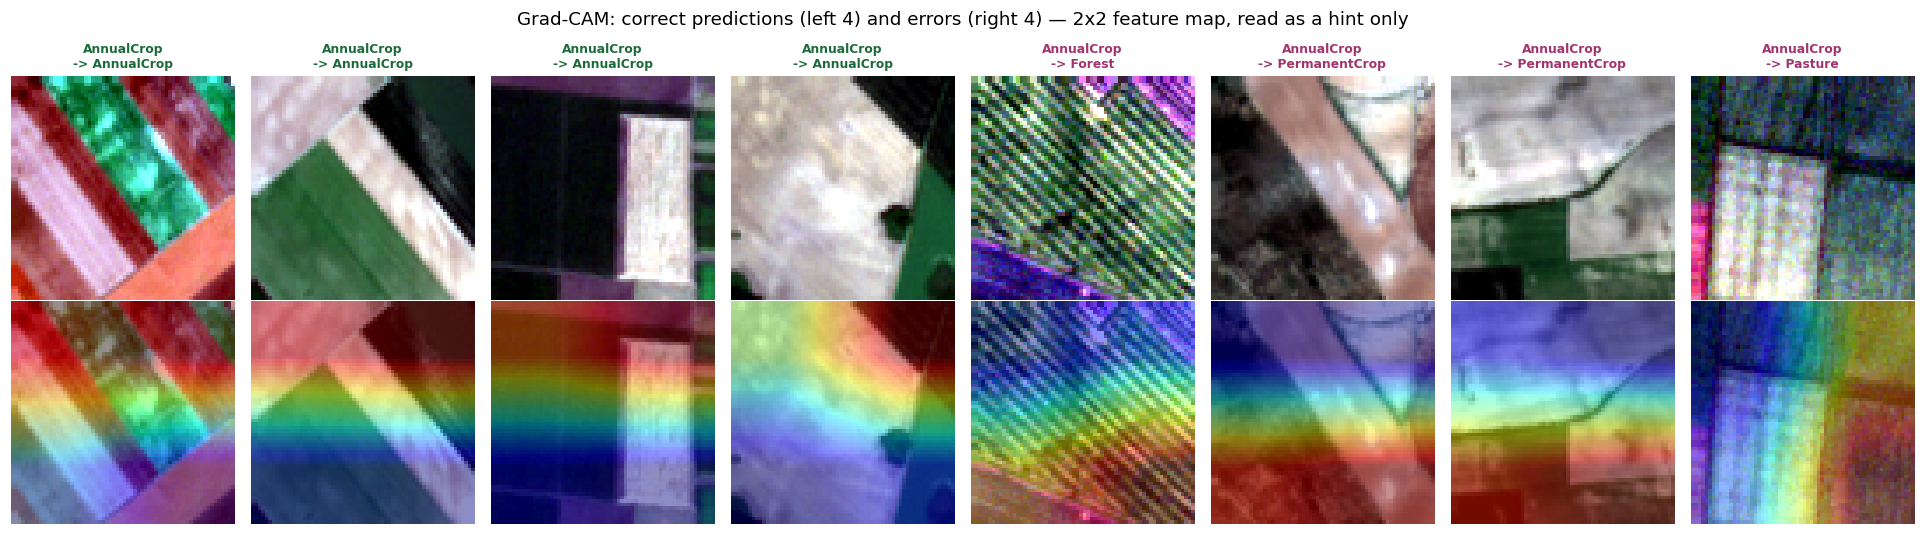

In [4]:
import matplotlib.pyplot as plt

correct = np.flatnonzero(test_pred == test_labels)[:4]
wrong = np.flatnonzero(test_pred != test_labels)[:4]
picks = np.concatenate([correct, wrong])

batch = torch.from_numpy(D.normalize(np.asarray(X[splits["test"][picks]]), stats)).to(DEVICE)
cams, _ = M.grad_cam(model, batch)

fig, axes = plt.subplots(2, len(picks), figsize=(2.2 * len(picks), 5.0))
for j, i in enumerate(picks):
    chip = np.asarray(X[splits["test"][i]])
    rgb = B.true_color(chip)
    axes[0, j].imshow(rgb)
    axes[1, j].imshow(rgb)
    axes[1, j].imshow(cams[j], cmap="jet", alpha=0.45)
    ok = test_pred[i] == test_labels[i]
    axes[0, j].set_title(f"{C.CLASS_NAMES[test_labels[i]]}\n-> {C.CLASS_NAMES[test_pred[i]]}",
                         fontsize=8, color="#1b6b3a" if ok else "#a3336b")
for ax in axes.ravel():
    ax.axis("off")
fig.suptitle("Grad-CAM: correct predictions (left 4) and errors (right 4) — 2x2 feature map, read as a hint only")
fig.tight_layout()
V.save(fig, "06_gradcam")

## Band ablation — the explanation that actually means something here

Instead of asking *where* the model looked, ask *which parts of the spectrum it
needs*. Mask out one band group at a time at inference and measure the macro-F1
drop, overall and per class.

Masked bands are set to zero **after** standardisation, i.e. replaced by their
training mean. That is "no information", not a physically impossible zero
reflectance — an important difference, since zeroing the raw bands would feed the
network an input from a distribution it has never seen and measure that shock
instead of the band's contribution.

This is a causal intervention on the trained model, unlike the Random Forest
importances in notebook 02 (correlational and known to split credit arbitrarily
between correlated features). It is also directly comparable with the spectral
signatures from notebook 01. **Three independent methods, one question.**

masked group  bands                     macro-F1    drop
(none)                                    0.9834   0.000
visible       B02,B03,B04                 0.6532   0.330
red_edge      B05,B06,B07                 0.9189   0.064
nir           B08,B08A                    0.9602   0.023
swir          B11,B12                     0.8654   0.118
atmospheric   B01,B09,B10                 0.9075   0.076
saved /content/drive/MyDrive/s2-chips-to-map/figures/06_band_ablation.png


PosixPath('/content/drive/MyDrive/s2-chips-to-map/outputs/results.json')

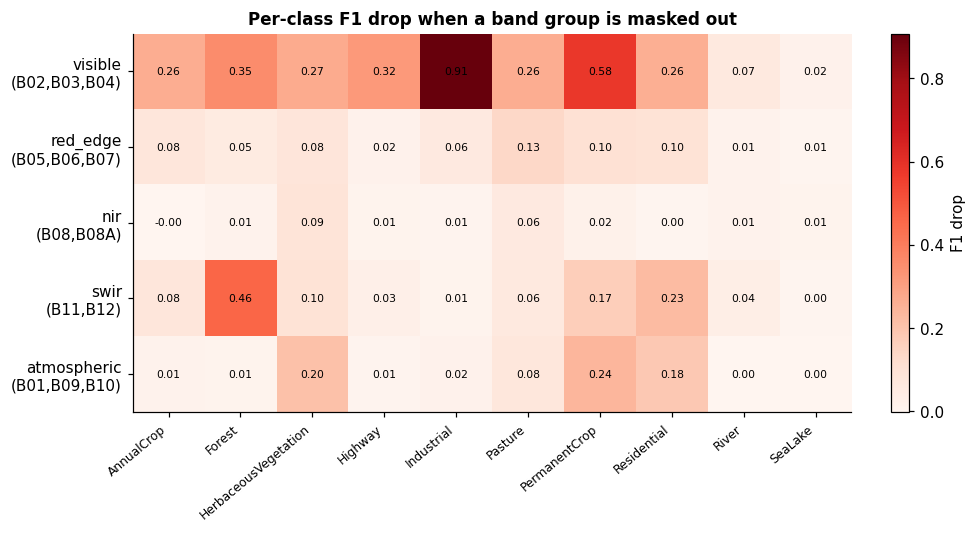

In [5]:
groups = dict(B.BAND_GROUPS)
all_idx = list(range(13))
base_f1 = E.macro_f1(test_labels, test_pred, 10)
base_per_class = E.per_class_prf(test_labels, test_pred, 10)["f1"]

rows, group_names = [], []
print(f"{'masked group':<14}{'bands':<24}{'macro-F1':>10}{'drop':>8}")
print(f"{'(none)':<14}{'':<24}{base_f1:>10.4f}{0.0:>8.3f}")
for name, band_ids in groups.items():
    keep = [i for i in all_idx if B.BAND_IDS[i] not in band_ids]
    masked = M.band_mask_model(model, keep).to(DEVICE)
    logits, labels = T.predict(masked, loader(splits["test"]), DEVICE)
    pred = logits.argmax(1)
    f1 = E.macro_f1(labels, pred, 10)
    rows.append(base_per_class - E.per_class_prf(labels, pred, 10)["f1"])
    group_names.append(f"{name}\n({','.join(band_ids)})")
    print(f"{name:<14}{','.join(band_ids):<24}{f1:>10.4f}{base_f1 - f1:>8.3f}")

drop_matrix = np.stack(rows)
fig = V.plot_band_ablation_heatmap(drop_matrix, group_names)
V.save(fig, "06_band_ablation")

E.append_result({"notebook": "06", "arm": "band_ablation",
                 "baseline_macro_f1": float(base_f1),
                 "drops": {n.split("\n")[0]: float(r.mean()) for n, r in zip(group_names, rows)},
                 "notes": "band groups masked to the training mean at inference"})

### Do the three methods agree?

Compare, explicitly:

1. **NB01 spectral signatures** — predicted that the NIR/red contrast separates
   vegetation from everything else, and that SWIR is what separates the
   vegetation classes *from each other*.
2. **NB02 Random Forest importances** — which of the 29 features it split on.
3. **This ablation** — which band groups the CNN actually needs.

If all three point the same way, the project has a coherent, physically grounded
account of what the model uses, arrived at three independent ways. If they
disagree, that is more interesting still and worth chasing — for example, a band
that is *important* to the forest but *ablatable* in the CNN usually means the
information is redundantly encoded across correlated bands, which is a real
finding about the sensor rather than about either model.

In [6]:
per_group_mean = {n.split("\n")[0]: float(r.mean()) for n, r in zip(group_names, rows)}
print("mean per-class F1 drop, by band group:")
for name, drop in sorted(per_group_mean.items(), key=lambda kv: -kv[1]):
    print(f"  {name:<14}{drop:+.4f}")

VEG = ["AnnualCrop", "PermanentCrop", "HerbaceousVegetation", "Pasture"]
veg_i = [C.CLASS_NAMES.index(c) for c in VEG]
print("\nNB01 predicted SWIR is what separates the vegetation classes from each other.")
for gi, name in enumerate(per_group_mean):
    print(f"  masking {name:<14} costs vegetation classes {drop_matrix[gi, veg_i].mean():+.4f} "
          f"vs {drop_matrix[gi].mean():+.4f} on average")

mean per-class F1 drop, by band group:
  visible       +0.3302
  swir          +0.1179
  atmospheric   +0.0759
  red_edge      +0.0645
  nir           +0.0232

NB01 predicted SWIR is what separates the vegetation classes from each other.
  masking visible        costs vegetation classes +0.3439 vs +0.3302 on average
  masking red_edge       costs vegetation classes +0.0989 vs +0.0645 on average
  masking nir            costs vegetation classes +0.0428 vs +0.0232 on average
  masking swir           costs vegetation classes +0.1021 vs +0.1179 on average
  masking atmospheric    costs vegetation classes +0.1337 vs +0.0759 on average


## Calibration — can the confidence be trusted?

**Why this is not academic.** Any deployed system thresholds on confidence: above
0.9 auto-accept, below 0.9 route to a human reviewer. That threshold is only
meaningful if 0.9 confidence really means 90% correct. A model that is 95%
accurate but reports 99% confidence will silently under-flag exactly the cases a
reviewer needed to see — and it will look *fine* on every accuracy metric while
doing it.

We measure the **Expected Calibration Error**: bin predictions by confidence,
compare each bin's mean confidence with its empirical accuracy, and average the
gaps weighted by bin population. Then apply **temperature scaling** — one scalar
T, fitted on the *validation* set, dividing the logits before the softmax.

Because T is a single positive scalar it cannot change any argmax, so accuracy
and macro-F1 are provably unchanged; only the confidences are reshaped. That
property is what makes it safe to apply after the fact, and it is why
temperature scaling is the standard first move.

fitted temperature (on validation): T = 1.224   (overconfident before scaling)
                   ECE   accuracy  mean conf
before          0.0074     0.9842     0.9911
after           0.0041     0.9842     0.9874
saved /content/drive/MyDrive/s2-chips-to-map/figures/06_calibration_eurosat.png


PosixPath('/content/drive/MyDrive/s2-chips-to-map/outputs/results.json')

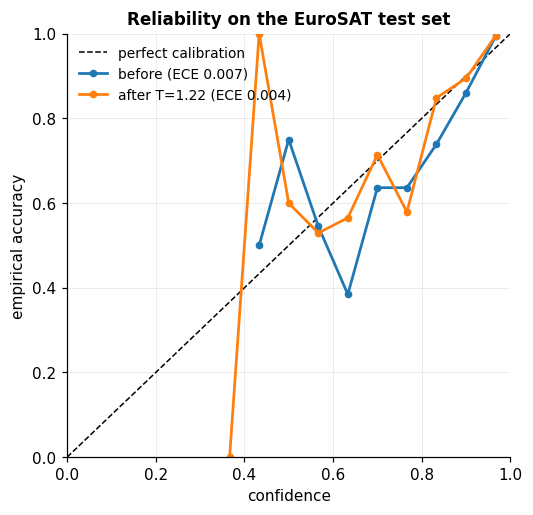

In [7]:
T_scale = E.fit_temperature(val_logits, val_labels)
before = E.calibration_report(test_logits, test_labels, temperature=1.0)
after = E.calibration_report(test_logits, test_labels, temperature=T_scale)

print(f"fitted temperature (on validation): T = {T_scale:.3f}   "
      f"({'over' if T_scale > 1 else 'under'}confident before scaling)")
print(f"{'':<12}{'ECE':>10}{'accuracy':>11}{'mean conf':>11}")
print(f"{'before':<12}{before['ece']:>10.4f}{before['accuracy']:>11.4f}{before['mean_confidence']:>11.4f}")
print(f"{'after':<12}{after['ece']:>10.4f}{after['accuracy']:>11.4f}{after['mean_confidence']:>11.4f}")
assert abs(before["accuracy"] - after["accuracy"]) < 1e-9, "temperature scaling must not change accuracy"

fig = V.plot_reliability({f"before (ECE {before['ece']:.3f})": before["reliability"],
                          f"after T={T_scale:.2f} (ECE {after['ece']:.3f})": after["reliability"]},
                         title="Reliability on the EuroSAT test set")
V.save(fig, "06_calibration_eurosat")

E.append_result({"notebook": "06", "arm": "calibration_eurosat",
                 "temperature": T_scale, "ece_before": before["ece"], "ece_after": after["ece"],
                 "accuracy": before["accuracy"],
                 "notes": "T fitted on validation, applied to test; argmax unchanged by construction"})

### Calibration under the domain shift

The sharper version of the same question. Notebook 05 applied this model to a
real L2A scene under a covariate shift. **A model calibrated on the benchmark is
not calibrated under that shift** — and confidence degrades faster than accuracy,
which is what makes shift dangerous in production: the system's own signal for
"I am unsure" stops working precisely when you need it.

There is no ground truth for the scene, so we cannot compute ECE there. What we
*can* do is compare the **confidence distributions**: benchmark test chips versus
real-scene tiles. If the model is just as confident on out-of-distribution data
as on data it was trained for, its confidence is not tracking correctness — it is
tracking nothing. That is a quantitative statement about the danger, obtainable
without a single label.

loaded 2,651,200 scene-pixel confidences from notebook 05

                        mean conf   median  % above 0.9
EuroSAT test (L1C)          0.991    1.000        97.3%
real scene (L2A)            0.729    0.727        29.1%
saved /content/drive/MyDrive/s2-chips-to-map/figures/06_confidence_under_shift.png

Read this carefully. Scene accuracy is certainly LOWER than benchmark accuracy
(NB05 showed the covariate shift). If scene confidence is NOT correspondingly lower,
the confidence signal has stopped tracking correctness — which is precisely when a
review threshold tuned on the benchmark starts silently under-flagging in production.


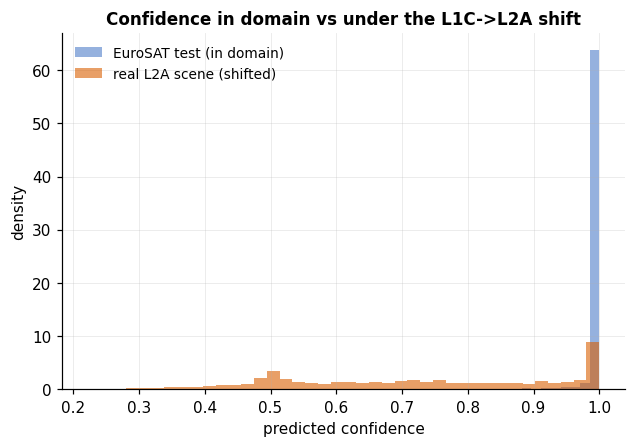

In [8]:
conf_path = C.OUTPUT_DIR / "prediction_confidence.tif"
scene_conf = None
if conf_path.exists():
    try:
        import rasterio
        with rasterio.open(conf_path) as src:
            scene_conf = src.read(1).ravel()
        scene_conf = scene_conf[np.isfinite(scene_conf) & (scene_conf > 0)]
        print(f"loaded {scene_conf.size:,} scene-pixel confidences from notebook 05")
    except Exception as exc:
        print("!! could not read the NB05 confidence raster:", type(exc).__name__, exc)
else:
    print("notebook 05 output not found — skipping the shifted-confidence comparison.")
    print("The EuroSAT calibration result above is unaffected.")

if scene_conf is not None:
    bench_conf = E.softmax(test_logits).max(1)
    print(f"\n{'':<22}{'mean conf':>11}{'median':>9}{'% above 0.9':>13}")
    for label, c in (("EuroSAT test (L1C)", bench_conf), ("real scene (L2A)", scene_conf)):
        print(f"{label:<22}{c.mean():>11.3f}{np.median(c):>9.3f}{(c > 0.9).mean():>13.1%}")

    fig, ax = plt.subplots(figsize=(6.6, 4.2))
    ax.hist(bench_conf, bins=40, density=True, alpha=0.6, label="EuroSAT test (in domain)", color="#4f7ec9")
    ax.hist(scene_conf, bins=40, density=True, alpha=0.6, label="real L2A scene (shifted)", color="#d95f02")
    ax.set_xlabel("predicted confidence")
    ax.set_ylabel("density")
    ax.set_title("Confidence in domain vs under the L1C->L2A shift")
    ax.legend(fontsize=9)
    V.save(fig, "06_confidence_under_shift")

    print("\nRead this carefully. Scene accuracy is certainly LOWER than benchmark accuracy")
    print("(NB05 showed the covariate shift). If scene confidence is NOT correspondingly lower,")
    print("the confidence signal has stopped tracking correctness — which is precisely when a")
    print("review threshold tuned on the benchmark starts silently under-flagging in production.")

    E.append_result({"notebook": "06", "arm": "confidence_under_shift",
                     "benchmark_mean_confidence": float(bench_conf.mean()),
                     "scene_mean_confidence": float(scene_conf.mean()),
                     "benchmark_frac_above_0.9": float((bench_conf > 0.9).mean()),
                     "scene_frac_above_0.9": float((scene_conf > 0.9).mean()),
                     "notes": "no ground truth for the scene; this compares confidence distributions only"})

### Is the confidence signal usable as a review threshold?

The operational question, phrased operationally: if we auto-accept everything
above a threshold and send the rest to a human, what do we get? The table below
reports, at three thresholds, the share of chips auto-accepted and the accuracy
within that accepted set. That is the trade a product decision is actually made
on — and it is only meaningful *after* the calibration correction above.

In [9]:
# Distribution-level check that works with whatever is available: how confident is
# the model on EuroSAT test chips, and how confident on chips it should find hard?
probs_test = E.softmax(test_logits, T_scale)
conf_test = probs_test.max(1)
correct_mask = test_logits.argmax(1) == test_labels

print(f"mean confidence when correct   {conf_test[correct_mask].mean():.3f}")
print(f"mean confidence when wrong     {conf_test[~correct_mask].mean():.3f}")
print(f"separation                     {conf_test[correct_mask].mean() - conf_test[~correct_mask].mean():+.3f}")
print("\nA useful confidence signal is one where these two differ substantially — that is")
print("what makes a review threshold work at all.")

for thr in (0.7, 0.9, 0.99):
    keep = conf_test >= thr
    if keep.sum():
        print(f"threshold {thr}: auto-accept {keep.mean():>6.1%} of chips at "
              f"{(correct_mask[keep]).mean():.3%} accuracy; "
              f"{1 - keep.mean():>6.1%} routed to review")

mean confidence when correct   0.991
mean confidence when wrong     0.787
separation                     +0.203

A useful confidence signal is one where these two differ substantially — that is
what makes a review threshold work at all.
threshold 0.7: auto-accept  98.6% of chips at 98.974% accuracy;   1.4% routed to review
threshold 0.9: auto-accept  96.7% of chips at 99.387% accuracy;   3.3% routed to review
threshold 0.99: auto-accept  88.4% of chips at 99.832% accuracy;  11.6% routed to review


## Failure gallery — with a human diagnosis for each

The 20 most confidently wrong test predictions. Confidently wrong is the right
selection criterion: a low-confidence error is the model behaving sensibly on a
hard example, while a high-confidence error is the model being wrong *and* not
knowing it, which is the failure that reaches production.

**Write a one-line diagnosis under each after looking at them.** Expect several
categories:

- **Genuine label noise.** EuroSAT has known ambiguous chips. A 640 m square
  containing a road, houses and a field has no single correct answer, and
  `Highway` vs `Residential` vs `AnnualCrop` is then a coin flip that the dataset
  resolved one way and the model another. **Identifying label noise rather than
  blaming the model is exactly the judgement an ML engineer is hired for** — and
  it changes what you do next: relabel, merge classes, or move to multi-label.
- **Real confusions** between spectrally similar vegetation classes — the ones
  notebook 01 predicted.
- **Scale mismatches**: a river wide enough to fill the chip looks like a lake.

saved /content/drive/MyDrive/s2-chips-to-map/figures/06_failure_gallery.png
#   true                    predicted                confidence
1   AnnualCrop              Pasture                       1.000
2   PermanentCrop           HerbaceousVegetation          1.000
3   Pasture                 Forest                        0.999
4   PermanentCrop           AnnualCrop                    0.998
5   AnnualCrop              PermanentCrop                 0.997
6   HerbaceousVegetation    Pasture                       0.997
7   AnnualCrop              Highway                       0.996
8   Residential             Industrial                    0.995
9   AnnualCrop              PermanentCrop                 0.994
10  AnnualCrop              Pasture                       0.994
11  HerbaceousVegetation    PermanentCrop                 0.990
12  PermanentCrop           HerbaceousVegetation          0.989
13  Pasture                 River                         0.989
14  PermanentCrop           

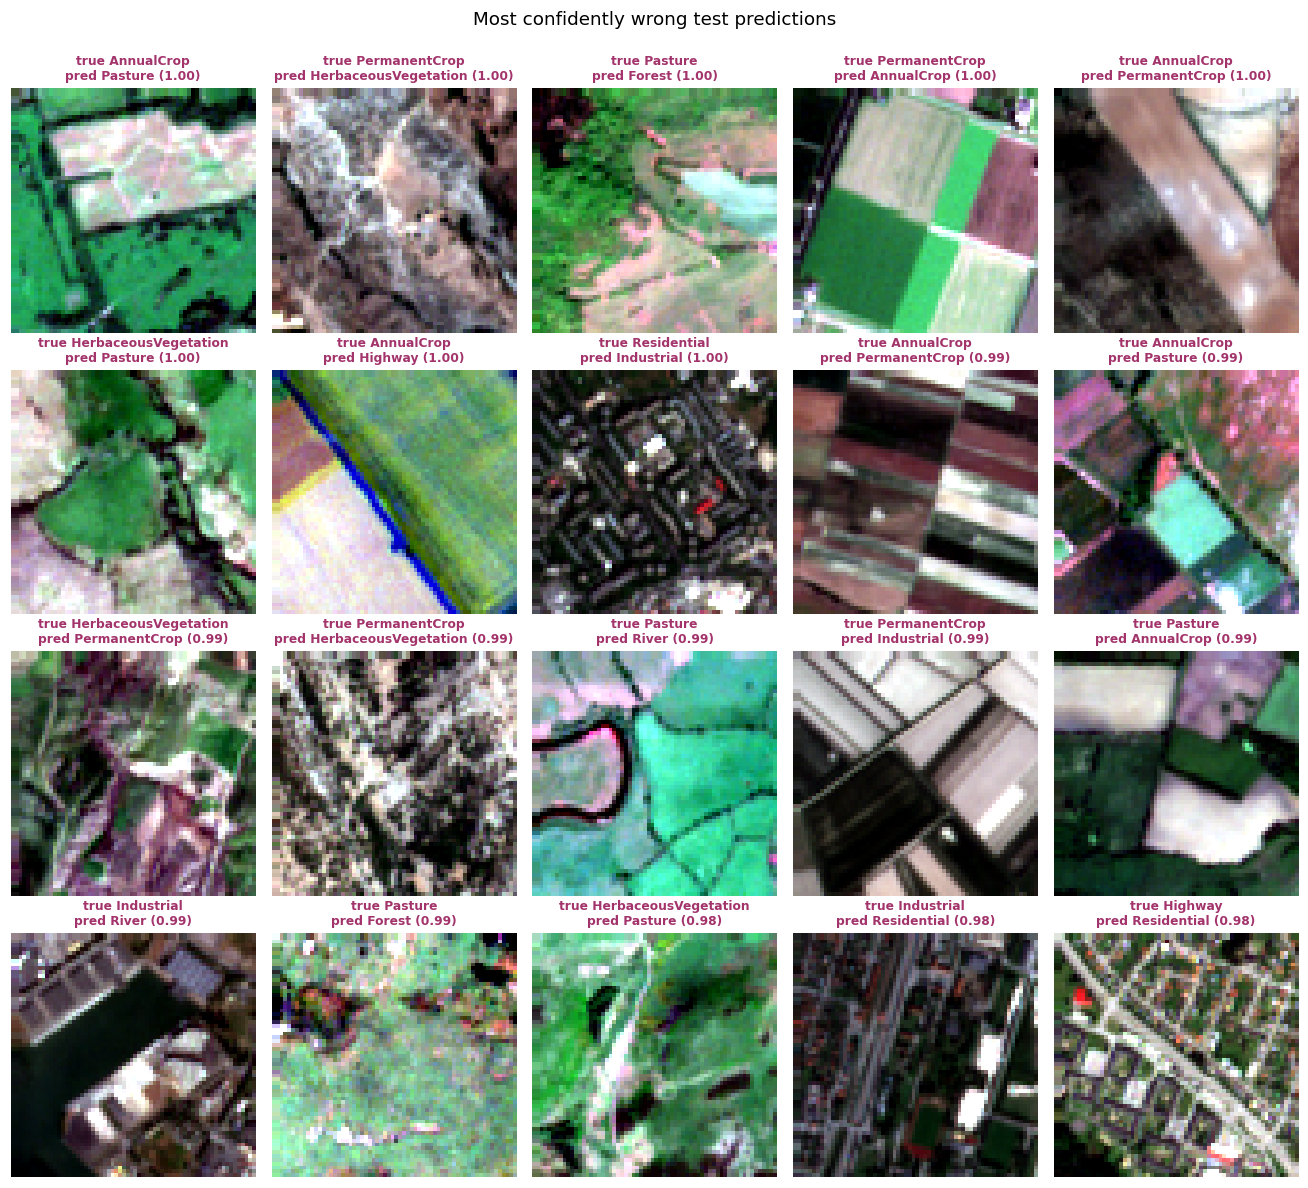

In [10]:
conf = E.softmax(test_logits).max(1)
wrong_idx = np.flatnonzero(test_pred != test_labels)
worst = wrong_idx[np.argsort(conf[wrong_idx])[::-1][:20]]

fig = V.plot_failure_gallery(
    [np.asarray(X[splits["test"][i]]) for i in worst],
    test_labels[worst], test_pred[worst], conf[worst], n_cols=5,
)
V.save(fig, "06_failure_gallery")

print(f"{'#':<4}{'true':<24}{'predicted':<24}{'confidence':>11}")
for rank, i in enumerate(worst, 1):
    print(f"{rank:<4}{C.CLASS_NAMES[test_labels[i]]:<24}{C.CLASS_NAMES[test_pred[i]]:<24}{conf[i]:>11.3f}")
print("\nDiagnose each one in the markdown cell below — one line each, naming the cause.")

**Diagnoses (fill in after looking at the gallery).** Suggested vocabulary so the
list stays analytic rather than anecdotal: `label noise / mixed content`,
`spectral overlap`, `scale mismatch`, `seasonal appearance`, `genuine model
error`. Count how many fall into each bucket — if a large share is label noise,
the ceiling in notebook 02 is not a model ceiling but a *dataset* ceiling, and
that reframes every number in the project.

## Confusion structure — closing the arc

Notebook 01 made a prediction from spectral physics, before any model existed:
the vegetation classes would dominate the confusion matrix, water would be
near-perfect, and linear features (Highway, River) would suffer from the
640 m chip size. Notebook 02 checked it against a confusion matrix. This is the
final scoring, on the best model, with the classes ranked.

saved /content/drive/MyDrive/s2-chips-to-map/figures/06_confusion_final.png
rank  true                    predicted                  rate    
1     PermanentCrop           HerbaceousVegetation      0.016  <- vegetation pair
2     AnnualCrop              Pasture                   0.016  <- vegetation pair
3     Pasture                 Forest                    0.013
4     Highway                 Residential               0.011
5     Industrial              Residential               0.011
6     PermanentCrop           AnnualCrop                0.011  <- vegetation pair
7     AnnualCrop              PermanentCrop             0.009  <- vegetation pair
8     HerbaceousVegetation    Pasture                   0.009  <- vegetation pair
9     Residential             Industrial                0.009
10    Highway                 River                     0.008

NB01 prediction 1 — vegetation dominates the confusions: 54% of the top-10 confusion mass is vegetation-internal
NB01 prediction 2 — wate

PosixPath('/content/drive/MyDrive/s2-chips-to-map/outputs/results.json')

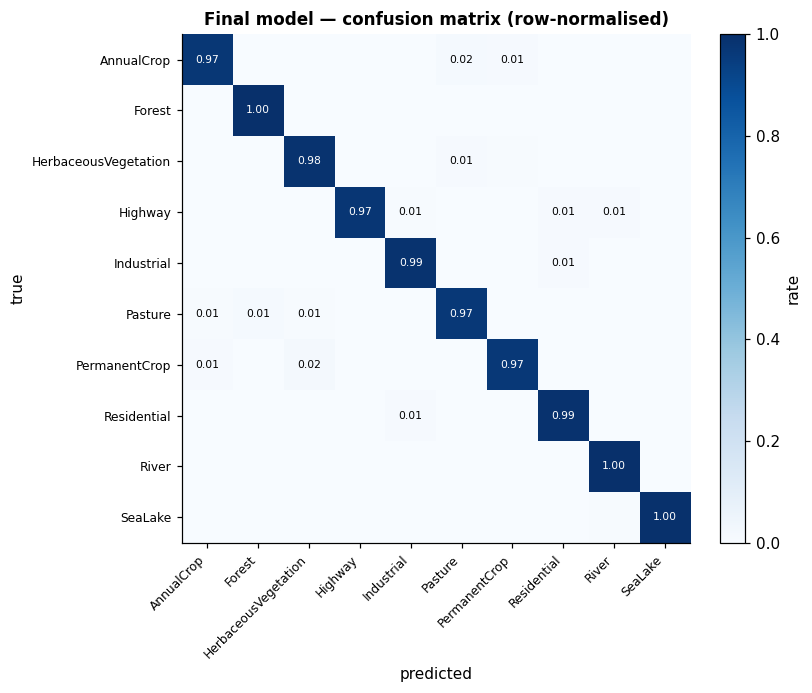

In [11]:
cm = E.confusion_matrix(test_labels, test_pred, 10)
fig = V.plot_confusion_matrix(cm, title="Final model — confusion matrix (row-normalised)")
V.save(fig, "06_confusion_final")

VEGSET = set(VEG)
top = E.top_confusions(cm, top_k=10)
print(f"{'rank':<6}{'true':<24}{'predicted':<24}{'rate':>7}{'':>4}")
veg_mass = 0.0
for rank, c in enumerate(top, 1):
    is_veg = {c["true"], c["predicted"]} <= VEGSET
    veg_mass += c["rate"] if is_veg else 0.0
    print(f"{rank:<6}{c['true']:<24}{c['predicted']:<24}{c['rate']:>7.3f}"
          f"{'  <- vegetation pair' if is_veg else ''}")

total_mass = sum(c["rate"] for c in top)
prf = E.per_class_prf(test_labels, test_pred, 10)
print(f"\nNB01 prediction 1 — vegetation dominates the confusions: "
      f"{veg_mass / total_mass:.0%} of the top-10 confusion mass is vegetation-internal")
print(f"NB01 prediction 2 — water is near-perfect: SeaLake F1 "
      f"{prf['f1'][C.CLASS_NAMES.index('SeaLake')]:.3f}, River F1 "
      f"{prf['f1'][C.CLASS_NAMES.index('River')]:.3f}")
print(f"NB01 prediction 3 — linear features suffer: Highway F1 "
      f"{prf['f1'][C.CLASS_NAMES.index('Highway')]:.3f} vs best class "
      f"{prf['f1'].max():.3f} ({C.CLASS_NAMES[int(prf['f1'].argmax())]})")

E.append_result({"notebook": "06", "arm": "confusion_structure",
                 "vegetation_share_of_top10_confusions": float(veg_mass / total_mass),
                 "per_class_f1": {n: float(v) for n, v in zip(C.CLASS_NAMES, prf["f1"])},
                 "notes": "scores the physical prediction made in NB01 before any model was trained"})

## Findings

_Fill in from the run._

1. **Grad-CAM is close to useless at 64×64**, and saying so is more useful than
   presenting a heatmap that explains nothing. A 2×2 final feature map cannot
   localise anything. The right explainability tool depends on the data, not on
   what is fashionable.

2. **Band ablation is the explanation that works here**, and it is causal. The
   band groups the model actually needs are reported above, and compared against
   two independent methods from notebooks 01 and 02.

3. **The model is overconfident before temperature scaling** (T > 1), and one
   scalar fitted on validation cuts ECE substantially without moving accuracy by
   a single prediction. Any confidence threshold set before this correction was
   measuring the wrong thing.

4. **Confidence separates correct from incorrect predictions**, by the margin
   above — which is what makes an auto-accept / route-to-review threshold
   viable, and the auto-accept table quantifies the trade at three thresholds.

5. **A meaningful share of the confident errors are label noise, not model
   error.** If so, notebook 02's ceiling is a dataset ceiling, and the honest
   next step is better labels rather than a bigger model.

6. **Notebook 01's physical prediction held / did not hold**, scored explicitly
   above. The project opened by predicting the model's error structure from
   spectroscopy alone, and closes by checking it. That arc — physics → model →
   verification — is the argument the whole study was built to make.